# 10 — Structural deformation surrogate on real solves

The crash/deformation-surrogate pattern on **real StructuralMechanicsApplication solves**: a
linear-static cantilever is solved for several tip loads, a surrogate learns the load →
displacement-field map, and `InferenceProcess` deploys it at an unseen load — the structural
counterpart of notebook 07's thermal recipe.

Availability-gated like the tests: this notebook needs `StructuralMechanicsApplication` and
`LinearSolversApplication` compiled.


In [1]:
from pathlib import Path

import numpy
import torch
import matplotlib.pyplot as plt

import KratosMultiphysics as Kratos
import KratosMultiphysics.kratos_utilities as kratos_utils

assert kratos_utils.CheckIfApplicationsAvailable(
    "StructuralMechanicsApplication", "LinearSolversApplication"), \
    "This notebook needs StructuralMechanicsApplication and LinearSolversApplication compiled."

import KratosMultiphysics.StructuralMechanicsApplication as SMA
from KratosMultiphysics.StructuralMechanicsApplication.structural_mechanics_analysis import StructuralMechanicsAnalysis
from KratosMultiphysics.PhysicsNeMoApplication.processes.inference import inference_process
from KratosMultiphysics.PhysicsNeMoApplication.training import training_utils
from KratosMultiphysics import pyvista_utilities as pv_utils

OUTPUT = Path("output")
OUTPUT.mkdir(exist_ok=True)

LENGTH, HEIGHT = 1.0, 0.1

_PROJECT_PARAMETERS = '''{
    "problem_data": {
        "problem_name": "cantilever", "parallel_type": "OpenMP",
        "start_time": 0.0, "end_time": 0.99, "echo_level": 0
    },
    "solver_settings": {
        "solver_type": "Static", "analysis_type": "linear",
        "model_part_name": "StructuralModelPart", "domain_size": 2,
        "model_import_settings": { "input_type": "use_input_model_part" },
        "material_import_settings": { "materials_filename": "" },
        "echo_level": 0,
        "rotation_dofs": false,
        "time_stepping": { "time_step": 1.0 }
    },
    "processes": {}, "output_processes": {}
}'''

def solve_cantilever(tip_load, divisions=8):
    """Builds and solves the clamped strip under a vertical tip load (total N)."""
    model = Kratos.Model()
    model_part = model.CreateModelPart("StructuralModelPart")
    model_part.ProcessInfo[Kratos.DOMAIN_SIZE] = 2
    model_part.SetBufferSize(2)
    for name in ("DISPLACEMENT", "REACTION", "POSITIVE_FACE_PRESSURE",
                 "NEGATIVE_FACE_PRESSURE", "VOLUME_ACCELERATION"):
        model_part.AddNodalSolutionStepVariable(Kratos.KratosGlobals.GetVariable(name))
    for name in ("POINT_LOAD", "LINE_LOAD", "SURFACE_LOAD"):
        model_part.AddNodalSolutionStepVariable(getattr(SMA, name))

    generator_geometry = Kratos.Quadrilateral2D4(
        Kratos.Node(1, 0.0, 0.0, 0.0), Kratos.Node(2, 0.0, HEIGHT, 0.0),
        Kratos.Node(3, LENGTH, HEIGHT, 0.0), Kratos.Node(4, LENGTH, 0.0, 0.0))
    domain = model_part.CreateSubModelPart("Domain")
    Kratos.StructuredMeshGeneratorProcess(generator_geometry, domain, Kratos.Parameters('''{
        "number_of_divisions": %d,
        "element_name": "SmallDisplacementElement2D3N",
        "condition_name": "LineCondition",
        "create_skin_sub_model_part": false
    }''' % divisions)).Execute()

    properties = next(iter(domain.Elements)).Properties
    properties.SetValue(Kratos.YOUNG_MODULUS, 210.0e9)
    properties.SetValue(Kratos.POISSON_RATIO, 0.3)
    properties.SetValue(Kratos.CONSTITUTIVE_LAW, SMA.LinearElasticPlaneStrain2DLaw())

    tip_nodes = [node for node in model_part.Nodes if abs(node.X - LENGTH) < 1e-8]
    condition_id = 0
    for node in model_part.Nodes:
        if abs(node.X) < 1e-8:
            node.Fix(Kratos.DISPLACEMENT_X)
            node.Fix(Kratos.DISPLACEMENT_Y)
    for node in tip_nodes:
        node.SetSolutionStepValue(SMA.POINT_LOAD, [0.0, -tip_load / len(tip_nodes), 0.0])
        condition_id += 1
        domain.CreateNewCondition("PointLoadCondition2D1N", condition_id, [node.Id], properties)

    StructuralMechanicsAnalysis(model, Kratos.Parameters(_PROJECT_PARAMETERS)).Run()
    return model, model_part

def displacements(model_part):
    return numpy.array([list(node.GetSolutionStepValue(Kratos.DISPLACEMENT))
                        for node in model_part.Nodes])

model, model_part = solve_cantilever(1.0e6)
tip = [node for node in model_part.Nodes if abs(node.X0 - LENGTH) < 1e-8]
print(f"tip deflection at 1 MN: {numpy.mean([n.GetSolutionStepValue(Kratos.DISPLACEMENT_Y) for n in tip]):.4e} m")


 |  /           |                  
 ' /   __| _` | __|  _ \   __|    
 . \  |   (   | |   (   |\__ \  
_|\_\_|  \__,_|\__|\___/ ____/
           Multi-Physics 10.4."2"-physicsnemo-application-e03638205c2-Release-x86_64
           Compiled for GNU/Linux and Python3.12 with GCC-13.3
Compiled with threading and MPI support. Threading support with OpenMP.
Maximum number of threads: 2.
Running without MPI.
Importing    KratosStructuralMechanicsApplication 
    KRATOS   ___|  |                   |                   |
           \___ \  __|  __| |   |  __| __| |   |  __| _` | |
                 | |   |    |   | (    |   |   | |   (   | |
           _____/ \__|_|   \__,_|\___|\__|\__,_|_|  \__,_|_| MECHANICS
Initializing KratosStructuralMechanicsApplication...
Importing    KratosConstitutiveLawsApplication 
Initializing KratosConstitutiveLawsApplication...
Importing    KratosPhysicsNeMoApplication 
 ______  _                _            ______        ______                           _ _      

Importing    LinearSolversApplication 
    Kratos  _     _                       ____        _
           | |   (_)_ __   ___  __ _ _ __/ ___|  ___ | |_   _____ _ __ ___
           | |   | | '_ \ / _ \/ _` | '__\___ \ / _ \| \ \ / / _ \ '__/ __|
           | |___| | | | |  __/ (_| | |   ___) | (_) | |\ V /  __/ |  \__ \
           |_____|_|_| |_|\___|\__,_|_|  |____/ \___/|_| \_/ \___|_|  |___/
Initializing KratosLinearSolversApplication...
Using Intel MKL version 2025.0.3 build 20251007
MKL processor: Intel(R) Advanced Vector Extensions 2 (Intel(R) AVX-2) with support of Intel(R) Deep Learning Boost (Intel(R) DL Boost)
Linear-Solver-Factory: Creating "pardiso_lu" as fastest available direct solver 
::[MechanicalSolver]:: : Finished initialization. 
[WARNING] DEPRECATION-Warning; AnalysisStage: ModifyAfterSolverInitialize is deprecated. Please, use ModifyBeforeSolutionLoop instead. 
::[KSM Simulation]:: : Analysis -START-  
::[KSM Simulation]:: : STEP:  1 
::[KSM Simulation]:: : TIME: 

## Solving the training loads

Three real solves span the load range. The linear response means
`u(load) = load · u_unit`; the surrogate's only parameter is the per-node unit displacement
field, fitted by the generic `TrainModel` loop from the solves.


In [2]:
LOAD_SCALE = 1.0e6
train_loads = (0.5e6, 1.0e6, 2.0e6)
samples = []
for load in train_loads:
    _, mp = solve_cantilever(load)
    samples.append((load, displacements(mp)))
n_nodes = samples[0][1].shape[0]
print(len(samples), "solves,", n_nodes, "nodes each")

class DeformationSurrogate(torch.nn.Module):
    def __init__(self, n_nodes):
        super().__init__()
        self.unit_displacements = torch.nn.Parameter(torch.zeros((n_nodes, 3), dtype=torch.float64))

    def forward(self, load_fraction):  # (N, 1) -> (N, 3)
        return load_fraction * self.unit_displacements

inputs = torch.stack([torch.full((n_nodes, 1), load / LOAD_SCALE, dtype=torch.float64)
                      for load, _ in samples])
targets = torch.stack([torch.tensor(u, dtype=torch.float64) for _, u in samples])
dataset = torch.utils.data.TensorDataset(inputs, targets)

surrogate = DeformationSurrogate(n_nodes)
history = training_utils.TrainModel(surrogate, dataset, Kratos.Parameters('''{
    "epochs": 400, "batch_size": 3, "learning_rate": 1e-3,
    "device": "auto", "seed": 0, "echo_interval": 100
}'''))
print(f"loss: {history[0]:.3e} -> {history[-1]:.3e}")

checkpoint = OUTPUT / "deformation_surrogate.pt"
torch.jit.script(surrogate).save(str(checkpoint))


::[MechanicalSolver]:: : Construction finished 
::[StaticMechanicalSolver]:: : Construction finished 
::[MechanicalSolver]:: : Variables ADDED 
::[PythonSolver]::: Reading model part. 
::[PythonSolver]::: Using already imported model part - no reading necessary. 
ModelPart: -StructuralModelPart- model part
    Buffer Size : 2
    Number of tables : 0
    Number of sub model parts : 1
    Current solution step index : 0
    DOMAIN_SIZE : 2
    OSS_SWITCH : 0
    IS_RESTARTED : 0

    Mesh 0 :
        Number of Nodes       : 81
        Number of Properties  : 1
        Number of Elements    : 128
        Number of Conditions  : 9
        Number of Geometries  : 0
        Number of Constraints : 0

    -Domain- model part
        Number of tables : 0
        Number of sub model parts : 0

        Mesh 0 :
            Number of Nodes       : 81
            Number of Properties  : 1
            Number of Elements    : 128
            Number of Conditions  : 9
            Number of Geometrie

TrainModel: epoch 100/400: loss = 5.191899e-11 


TrainModel: epoch 200/400: loss = 2.801733e-15 


TrainModel: epoch 300/400: loss = 3.375281e-20 


TrainModel: epoch 400/400: loss = 1.695018e-24 
loss: 6.605e-06 -> 1.695e-24


## Deployment at an unseen load

The load parameter travels as a constant nodal field (`POSITIVE_FACE_PRESSURE` — already in the
solver's variable list) and `InferenceProcess` writes the predicted field into
`MESH_DISPLACEMENT`, next to the solver's true `DISPLACEMENT` for comparison.


In [3]:
test_load = 1.5e6
model, model_part = solve_cantilever(test_load)
reference = displacements(model_part)

for node in model_part.Nodes:
    node.SetSolutionStepValue(Kratos.POSITIVE_FACE_PRESSURE, test_load / LOAD_SCALE)

process = inference_process.Factory(Kratos.Parameters('''{
    "Parameters": {
        "model_part_name": "StructuralModelPart",
        "model_settings": { "checkpoint_file": "%s", "device": "auto" },
        "input_fields":  [ { "variable_name": "POSITIVE_FACE_PRESSURE", "data_location": "node_historical" } ],
        "output_fields": [ { "variable_name": "MESH_DISPLACEMENT", "data_location": "node_non_historical" } ]
    }
}''' % checkpoint), model)
model_part.ProcessInfo[Kratos.STEP] = 1
process.ExecuteFinalizeSolutionStep()

predicted = numpy.array([list(node.GetValue(Kratos.MESH_DISPLACEMENT)) for node in model_part.Nodes])
scale = numpy.abs(reference).max()
print(f"max |u|:                      {scale:.4e} m")
print(f"max |predicted - reference|:  {numpy.abs(predicted - reference).max():.4e} m")
print(f"relative error:               {numpy.abs(predicted - reference).max() / scale:.2e}")


::[MechanicalSolver]:: : Construction finished 
::[StaticMechanicalSolver]:: : Construction finished 
::[MechanicalSolver]:: : Variables ADDED 
::[PythonSolver]::: Reading model part. 
::[PythonSolver]::: Using already imported model part - no reading necessary. 
ModelPart: -StructuralModelPart- model part
    Buffer Size : 2
    Number of tables : 0
    Number of sub model parts : 1
    Current solution step index : 0
    DOMAIN_SIZE : 2
    OSS_SWITCH : 0
    IS_RESTARTED : 0

    Mesh 0 :
        Number of Nodes       : 81
        Number of Properties  : 1
        Number of Elements    : 128
        Number of Conditions  : 9
        Number of Geometries  : 0
        Number of Constraints : 0

    -Domain- model part
        Number of tables : 0
        Number of sub model parts : 0

        Mesh 0 :
            Number of Nodes       : 81
            Number of Properties  : 1
            Number of Elements    : 128
            Number of Conditions  : 9
            Number of Geometrie

## Visualizing the deformation

The cantilever mesh warped by the exact Kratos solve, next to the same mesh warped by the surrogate's predicted `MESH_DISPLACEMENT` — rendered with the core pyvista bridge (`KratosMultiphysics.pyvista_utilities`); the pale ghost outline is the undeformed geometry.

/home/vicente/.local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


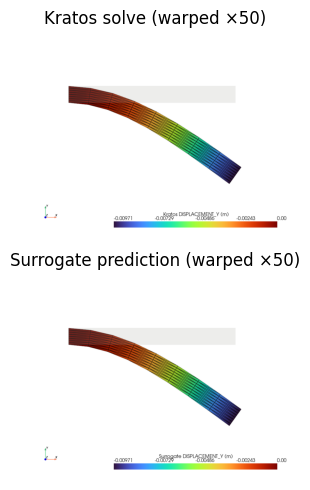

In [4]:
p_exact = pv_utils.PlotModelPart(
    model_part, warpByVector=Kratos.DISPLACEMENT, factor=50.0,
    name=Kratos.DISPLACEMENT, component=1, cmap="turbo",
    label="Kratos DISPLACEMENT_Y (m)", showUndeformed=True, view="xy", offScreen=True)
exact_img = p_exact.screenshot(None)

p_pred = pv_utils.PlotModelPart(
    model_part, warpByVector=Kratos.MESH_DISPLACEMENT, factor=50.0,
    name=Kratos.MESH_DISPLACEMENT, component=1, cmap="turbo",
    label="Surrogate DISPLACEMENT_Y (m)", showUndeformed=True, view="xy", offScreen=True)
predicted_img = p_pred.screenshot(None)

fig, axes = plt.subplots(2, 1, figsize=(8, 5))
axes[0].imshow(exact_img); axes[0].set_title("Kratos solve (warped \u00d750)"); axes[0].axis("off")
axes[1].imshow(predicted_img); axes[1].set_title("Surrogate prediction (warped \u00d750)"); axes[1].axis("off")
plt.tight_layout()
plt.savefig(OUTPUT / "deformation_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## Where to go from here

- Richer parametrizations (load position, material, geometry) call for a real network over
  per-node features — `PointCloudInferenceProcess` feeds coordinates + fields to
  point-cloud models directly.
- Nonlinear responses (contact, plasticity, crash) break the unit-field trick; export
  solve series with `DatasetExportProcess` and train on the full dataset.
- The active-learning loop (notebook 04) picks which loads to solve next; the
  solver-residual query strategy scores candidates with the real assembled residual.
